In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn import metrics
import numpy as np

In [4]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

display(df_train.head())
print("*"*50)
display(df_test.head())

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


**************************************************


,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,49,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy


In [8]:
display(df_train.info())
print("*"*50)
display(df_test.info())

<class 'pandas.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  str    
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  str    
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  str    
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  str    
 8   Landmarks      77299 non-null  str    
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  str    
dtypes: float64(2), int64(3), str(6)
memory usage: 6.5 MB


None

**************************************************
<class 'pandas.DataFrame'>
RangeIndex: 41778 entries, 0 to 41777
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          41778 non-null  int64  
 1   geohash        41778 non-null  str    
 2   day            41778 non-null  int64  
 3   timestamp      41778 non-null  str    
 4   RoadType       41454 non-null  str    
 5   NumberofLanes  41778 non-null  int64  
 6   LargeVehicles  41778 non-null  str    
 7   Landmarks      41778 non-null  str    
 8   Temperature    40429 non-null  float64
 9   Weather        41347 non-null  str    
dtypes: float64(1), int64(3), str(6)
memory usage: 3.2 MB


None

In [12]:
print("Missing values in Train")
print(df_train.isnull().sum()[df_train.isnull().sum() > 0])
print("*"*50)
print("Missing values in Test")

print(df_test.isnull().sum()[df_test.isnull().sum() > 0])


Missing values in Train
RoadType        600
Temperature    2495
Weather         797
dtype: int64
**************************************************
Missing values in Test
RoadType        324
Temperature    1349
Weather         431
dtype: int64


In [13]:
print("Demand Description")
print(df_train['demand'].describe())

Demand Description
count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64


In [14]:
print("Unique Values in Categoricals")
print("Unique Geohashes:", df_train['geohash'].nunique())
print("Weather Types:\n", df_train['Weather'].value_counts(dropna=False))
print("Road Types:\n", df_train['RoadType'].value_counts(dropna=False))

Unique Values in Categoricals
Unique Geohashes: 1249
Weather Types:
 Weather
Sunny    27717
Rainy    20824
Foggy    20243
Snowy     7718
NaN        797
Name: count, dtype: int64
Road Types:
 RoadType
Residential    69230
Street          3909
Highway         3560
NaN              600
Name: count, dtype: int64


In [15]:
print("Unique Days")
print("Number of unique days:", df_train['day'].nunique())
print("Min Day:", df_train['day'].min(), "| Max Day:", df_train['day'].max())

Unique Days
Number of unique days: 2
Min Day: 48 | Max Day: 49


In [16]:
def preprocess_data(df, train_geo_freq=None):
    df = df.copy()
    
    df['Temperature'] = df['Temperature'].fillna(df['Temperature'].median())
    df['RoadType'] = df['RoadType'].fillna('Unknown')
    df['Weather'] = df['Weather'].fillna('Unknown')
    
    def time_to_minutes(ts):
        try:
            h, m = map(int, ts.split(':'))
            return h * 60 + m
        except:
            return -1 # Fallback for bad data
            
    df['time_in_mins'] = df['timestamp'].apply(time_to_minutes)

    #If this is the training set, calculate frequencies. 
    #If it's the test set, map the training frequencies over to prevent leakage.
    if train_geo_freq is None:
        train_geo_freq = df['geohash'].value_counts().to_dict()
    
    #if a new geohash appears in test, fill with 1
    df['geo_freq'] = df['geohash'].map(train_geo_freq).fillna(1)
    
    df['LargeVehicles'] = df['LargeVehicles'].map({'Allowed': 1, 'Not Allowed': 0}).fillna(0)
    df['Landmarks'] = df['Landmarks'].map({'Yes': 1, 'No': 0}).fillna(0)
    
    df = pd.get_dummies(df, columns=['RoadType', 'Weather'], drop_first=False)
    
    df = df.drop(columns=['timestamp', 'geohash'])
    
    return df, train_geo_freq

train_clean, geo_mapping = preprocess_data(df_train)

test_clean, _ = preprocess_data(df_test, train_geo_freq=geo_mapping)

print("Cleaned Train Shape:", train_clean.shape)
print("Cleaned Test Shape:", test_clean.shape)
print("\nSample of clean train data:")
display(train_clean.head(3))

Cleaned Train Shape: (77299, 18)
Cleaned Test Shape: (41778, 17)

Sample of clean train data:


,Index,day,demand,NumberofLanes,LargeVehicles,Landmarks,Temperature,time_in_mins,geo_freq,RoadType_Highway,RoadType_Residential,RoadType_Street,RoadType_Unknown,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Sunny,Weather_Unknown
0,0,48,0.048804,1,0,0,16.382587,0,33,False,False,False,True,False,False,False,False,True
1,1,48,0.118507,3,1,1,31.104565,0,89,False,True,False,False,False,False,False,True,False
2,2,48,0.027132,1,0,0,25.919267,0,67,False,True,False,False,False,False,False,True,False


In [27]:
# Calculate the average demand for each geohash
geo_target_map = df_train.groupby('geohash')['demand'].mean().to_dict()
global_mean_demand = df_train['demand'].mean()

# Map these averages to our cleaned datasets
train_clean['geo_target_enc'] = df_train['geohash'].map(geo_target_map)

# For the test set, if a geohash is new, we give it the global average
test_clean['geo_target_enc'] = df_test['geohash'].map(geo_target_map).fillna(global_mean_demand)

In [28]:
X = train_clean.drop(columns=['Index', 'demand'])
y = train_clean['demand']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

In [30]:
model_v3 = xgb.XGBRegressor(
    n_estimators=800,       
    learning_rate=0.03,   
    max_depth=7,
    colsample_bytree=0.7,      
    random_state=42,
    objective='reg:squarederror'
)

model_v3.fit(
    X_train, y_train_log,      
    eval_set=[(X_val, y_val_log)],
    verbose=100 
)

[0]	validation_0-rmse:0.10682
[100]	validation_0-rmse:0.03137
[200]	validation_0-rmse:0.02980
[300]	validation_0-rmse:0.02946
[400]	validation_0-rmse:0.02935
[500]	validation_0-rmse:0.02915
[600]	validation_0-rmse:0.02906
[700]	validation_0-rmse:0.02900
[799]	validation_0-rmse:0.02897


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [32]:

X_test = test_clean.drop(columns=['Index'])

# Predict, reverse log, and clip
test_preds = model_v3.predict(X_test)
test_preds = np.expm1(test_preds) 
test_preds = np.clip(test_preds, 0, a_max=None) 

submission_v3 = pd.DataFrame({
    'Index': test_clean['Index'],
    'demand': test_preds
})

submission_v3.to_csv('submission_v3.csv', index=False)


<Figure size 1000x600 with 0 Axes>

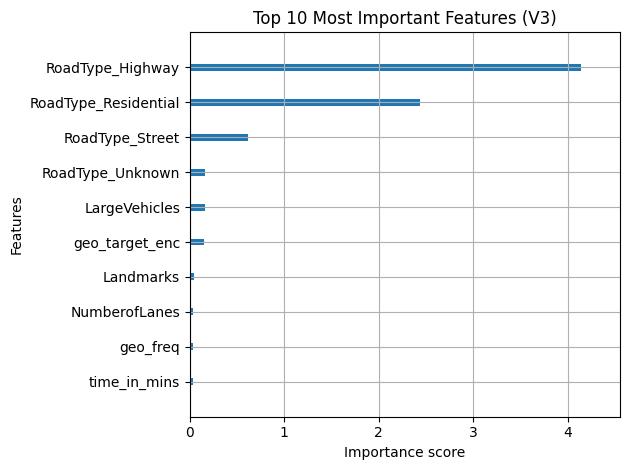

In [33]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(model_v3, max_num_features=10, importance_type='gain', show_values=False)
plt.title("Top 10 Most Important Features (V3)")
plt.tight_layout()
plt.show()

Shape: (41778, 2)(41778 x 2)
